1. Use sklearn's PolynomialFeatures() to transform a dataset of mobile phone prices (features: RAM, storage) into polynomial features up to degree 2, and print the resulting feature matrix.


In [1]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures

# Load dataset
df = pd.read_csv("mobile_prices.csv")

# Features
X = df[["RAM", "Storage"]]

# Polynomial Features (Degree = 2)
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

print("Feature Names:")
print(poly.get_feature_names_out(["RAM", "Storage"]))

print("\nPolynomial Feature Matrix:")
print(X_poly)

Feature Names:
['1' 'RAM' 'Storage' 'RAM^2' 'RAM Storage' 'Storage^2']

Polynomial Feature Matrix:
[[1.00000e+00 4.00000e+00 6.40000e+01 1.60000e+01 2.56000e+02 4.09600e+03]
 [1.00000e+00 6.00000e+00 1.28000e+02 3.60000e+01 7.68000e+02 1.63840e+04]
 [1.00000e+00 8.00000e+00 1.28000e+02 6.40000e+01 1.02400e+03 1.63840e+04]
 [1.00000e+00 8.00000e+00 2.56000e+02 6.40000e+01 2.04800e+03 6.55360e+04]
 [1.00000e+00 1.20000e+01 2.56000e+02 1.44000e+02 3.07200e+03 6.55360e+04]
 [1.00000e+00 1.60000e+01 5.12000e+02 2.56000e+02 8.19200e+03 2.62144e+05]]


2. Train both a LinearRegression and a Polynomial Regression (degree=3) model on a dataset of Zomato restaurant ratings versus number of reviews, then plot both predictions on the same chart to compare their fits.<br><br><em><strong>Hint:</strong> Use matplotlib for plotting and clearly label both curves.</em>

c:\Users\tejal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\tejal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


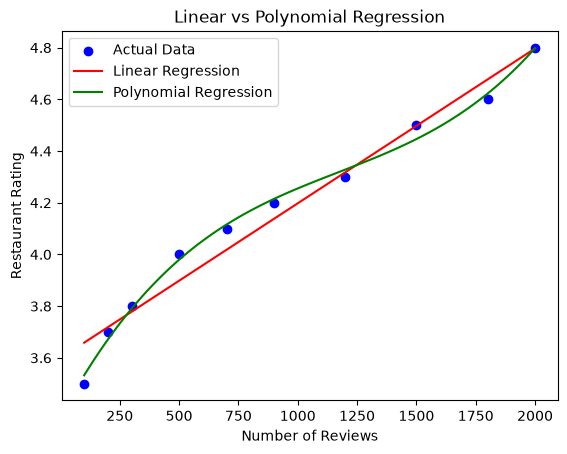

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Load dataset
df = pd.read_csv("zomato_reviews.csv")

X = df[["Reviews"]]
y = df["Rating"]

# Linear Regression
linear = LinearRegression()
linear.fit(X, y)

# Polynomial Regression (Degree = 3)
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

# Predictions
x_range = np.linspace(X.min(), X.max(), 100)

linear_pred = linear.predict(x_range)

poly_pred = poly_model.predict(poly.transform(x_range))

# Plot
plt.scatter(X, y, color="blue", label="Actual Data")

plt.plot(x_range, linear_pred, color="red", label="Linear Regression")

plt.plot(x_range, poly_pred, color="green", label="Polynomial Regression")

plt.xlabel("Number of Reviews")
plt.ylabel("Restaurant Rating")

plt.title("Linear vs Polynomial Regression")

plt.legend()

plt.show()

3. Given a dataset where the relationship between followers and posts for Instagram users is non-linear, fit a polynomial regression model (degree=4) and check for overfitting by plotting the training and validation errors for degrees 1 to 5.

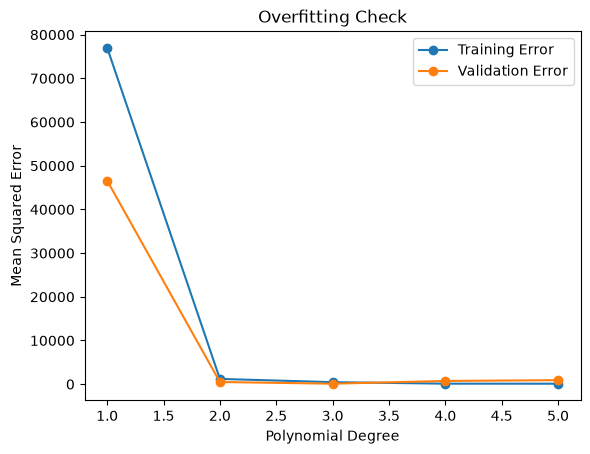

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

df = pd.read_csv("instagram_followers.csv")

X = df[["Posts"]]
y = df["Followers"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

train_error = []
test_error = []

for degree in range(1,6):

    poly = PolynomialFeatures(degree)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()

    model.fit(X_train_poly, y_train)

    train_pred = model.predict(X_train_poly)
    test_pred = model.predict(X_test_poly)

    train_error.append(mean_squared_error(y_train, train_pred))
    test_error.append(mean_squared_error(y_test, test_pred))

plt.plot(range(1,6), train_error, marker="o", label="Training Error")
plt.plot(range(1,6), test_error, marker="o", label="Validation Error")

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")

plt.title("Overfitting Check")

plt.legend()

plt.show()

4. Add L2 regularization (Ridge regression) to your polynomial regression model (degree=3) on a Flipkart product price prediction dataset, and compare the model's performance with and without regularization.<br><br><em><strong>Hint:</strong> Use Ridge from sklearn.linear_model and explain any difference in test error.</em>

In [4]:
import pandas as pd

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

df = pd.read_csv("flipkartttt_prices.csv")

X = df[["RAM","Storage"]]
y = df["Price"]

poly = PolynomialFeatures(degree=3)

X_poly = poly.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(
    X_poly,
    y,
    test_size=0.30,
    random_state=42
)

# Polynomial Regression
lr = LinearRegression()

lr.fit(X_train,y_train)

pred1 = lr.predict(X_test)

# Ridge Regression
ridge = Ridge(alpha=1.0)

ridge.fit(X_train,y_train)

pred2 = ridge.predict(X_test)

print("Polynomial Regression MSE")
print(mean_squared_error(y_test,pred1))

print()

print("Ridge Regression MSE")
print(mean_squared_error(y_test,pred2))

Polynomial Regression MSE
640027013.4387292

Ridge Regression MSE
640027516.5412365


c:\Users\tejal\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.85977e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


5. Use ChatGPT or Copilot to generate Python code that demonstrates underfitting and overfitting using polynomial regression on a synthetic dataset, then run the code and explain in your own words how model degree affects bias and variance.

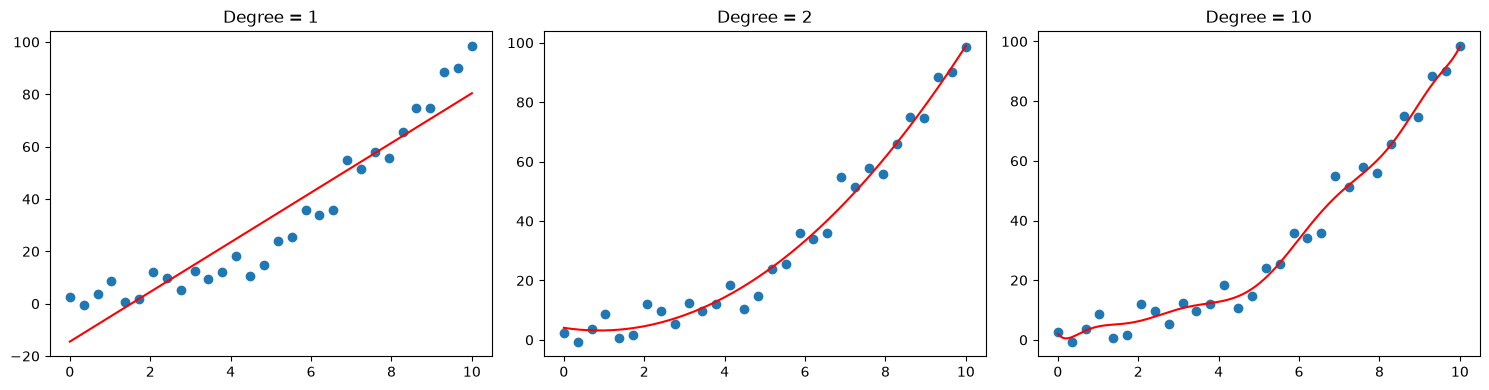

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Synthetic dataset
np.random.seed(42)

X = np.linspace(0,10,30).reshape(-1,1)

y = X.ravel()**2 + np.random.normal(0,5,30)

degrees = [1,2,10]

plt.figure(figsize=(15,4))

for i,degree in enumerate(degrees):

    poly = PolynomialFeatures(degree)

    X_poly = poly.fit_transform(X)

    model = LinearRegression()

    model.fit(X_poly,y)

    X_new = np.linspace(0,10,200).reshape(-1,1)

    y_pred = model.predict(poly.transform(X_new))

    plt.subplot(1,3,i+1)

    plt.scatter(X,y)

    plt.plot(X_new,y_pred,color="red")

    plt.title(f"Degree = {degree}")

plt.tight_layout()

plt.show()